# Lab 3 — Tiny RSSM: 循环状态空间模型

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab03_tiny_rssm/notebook.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 3**

Lab 2 我们训练了确定性的 Encoder → Dynamics → Decoder，并看到 open-loop rollout 的 drift。但它有一个更深的缺陷：给定历史，它只能预测**一个**未来。而真实世界（包括我们这个加了随机扰动的小球）是**随机的 (stochastic)**——同一段历史可以对应多个同样合理的未来。对随机未来取"唯一答案"的模型，只能输出所有可能未来的**平均**：一个模糊的影子。

本实验实现 PlaNet / Dreamer 的核心架构——**RSSM (Recurrent State-Space Model)**，把潜状态拆成两半：

```
确定性路径:  h_t = GRU(h_{t-1}, z_{t-1}, a_{t-1})     ← 记忆，管长程依赖
随机性路径:  z_t ~ prior p(z_t | h_t)                  ← 不确定性，管多模未来
推断:        z_t ~ posterior q(z_t | h_t, x_t)        ← 看了观测之后的修正
生成:        x̂_t = Decoder(h_t, z_t)
```

全程核心逻辑（GRU cell、prior/posterior 高斯、reparameterization、KL 闭式解）都是 notebook 里可见的几十行 PyTorch，没有黑盒。

## 1. Motivation — 三个问题

Lab 1 的 Kalman Filter 已经给出范式：**predict**（动力学外推，不确定性膨胀）+ **update**（观测校正，不确定性收缩）。Lab 2 的确定性模型只有 predict 的一半，且无法表达"我不确定"。RSSM 就是这套范式的大规模学习版：predict 由 prior + GRU 完成，update 由 posterior 完成。

本实验用实验回答三个问题：

1. **为什么纯 deterministic RNN 不够？** → Section 8 训练一个结构完全相同的 deterministic-only baseline，看它在随机未来上退化成模糊平均。
2. **为什么需要 stochastic latent state？** → Section 3 先证明环境本身"同一历史、多个未来"；Section 7 展示 RSSM 能采样出多个**各自清晰**的未来。
3. **为什么训练用 posterior、想象用 prior？** → Section 5（训练信号从哪来）与 Section 7（想象时没有观测可用）分别回答，KL 项负责把两者对齐。

## 2. Setup

**Why:** 唯一重的依赖是 PyTorch（CPU 版足够，Colab 已预装）。`imageio` 用来保存 imagination rollout 的 GIF。首格自动检测 Colab 环境并补装缺失包，全部实验在 CPU 上几分钟内跑完。

In [1]:
# @title setup
import sys, subprocess

IN_COLAB = "google.colab" in sys.modules

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg, name in [("torch", "torch"), ("imageio", "imageio"), ("matplotlib", "matplotlib")]:
    ensure(pkg, name)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import imageio.v2 as imageio

%matplotlib inline
os.makedirs("assets", exist_ok=True)
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__, "| device: cpu | colab:", IN_COLAB)


torch 2.8.0 | device: cpu | colab: False


## 3. Environment & Dataset: 带随机性的 Moving Ball

**Why:** 我们复用 Lab 0/2 的小球物理（force action、friction、wall bounce），但加了一个关键改动——**每一步速度都受到一个随机扰动**（可以想象成随机阵风）。这样即使给定完全相同的历史和动作序列，未来轨迹也不再唯一：这正是 stochastic latent 要建模的东西。

数据在代码内生成，无需下载：300 个 episode × 20 步，64×64 灰度帧 + 2 维 force action。

frames: torch.Size([300, 20, 1, 64, 64])  actions: torch.Size([300, 20, 2])


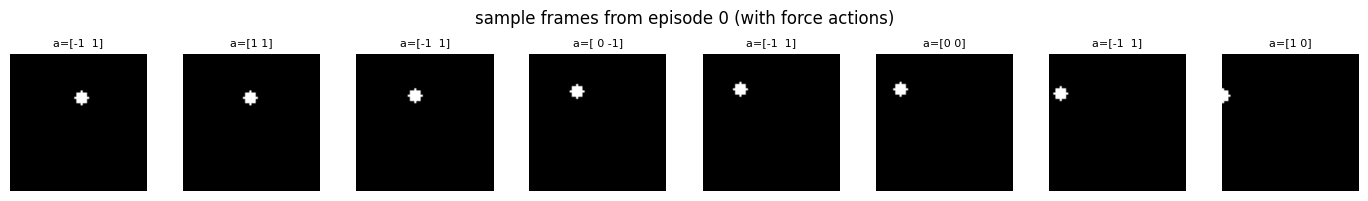

In [2]:
SIZE, N_EP, EP_LEN = 64, 300, 20        # 帧大小 / episode 数 / 每 episode 步数
DT, FRICTION, BOUNCE, FORCE = 0.1, 0.95, 0.9, 2.0
NOISE_STD = 0.1                         # 每步速度随机扰动 —— 环境的固有随机性

def render_ball(x, y, size=SIZE):
    img = np.zeros((size, size), dtype=np.float32)
    px = int(np.clip(x, 0, 1) * (size - 1))
    py = int(np.clip(y, 0, 1) * (size - 1))
    yy, xx = np.mgrid[0:size, 0:size]
    img[(xx - px) ** 2 + (yy - py) ** 2 <= 3 ** 2] = 1.0
    return img

def step_world(state, a, rng):
    """one physics step; the random velocity kick makes the world stochastic"""
    x, y, vx, vy = state
    vx = (vx + FORCE * a[0] * DT) * FRICTION + rng.normal(0, NOISE_STD)
    vy = (vy + FORCE * a[1] * DT) * FRICTION + rng.normal(0, NOISE_STD)
    x, y = x + vx * DT, y + vy * DT
    if x < 0: x, vx = -x, -vx * BOUNCE
    if x > 1: x, vx = 2 - x, -vx * BOUNCE
    if y < 0: y, vy = -y, -vy * BOUNCE
    if y > 1: y, vy = 2 - y, -vy * BOUNCE
    return (x, y, vx, vy)

def simulate_episode(rng, ep_len=EP_LEN):
    state = (*rng.uniform(0.15, 0.85, 2), *rng.uniform(-0.5, 0.5, 2))
    frames, actions = [], []
    for t in range(ep_len):
        a = rng.integers(-1, 2, 2).astype(np.float32)
        state = step_world(state, a, rng)
        frames.append(render_ball(state[0], state[1]))
        actions.append(a)
    return np.stack(frames), np.stack(actions)

rng = np.random.default_rng(0)
episodes = [simulate_episode(rng) for _ in range(N_EP)]
frames_np = np.stack([e[0] for e in episodes])            # (N_EP, EP_LEN, 64, 64)
actions_np = np.stack([e[1] for e in episodes])           # (N_EP, EP_LEN, 2)
frames_t = torch.from_numpy(frames_np).unsqueeze(2)       # (N_EP, T, 1, 64, 64)
actions_t = torch.from_numpy(actions_np)                  # (N_EP, T, 2)
print(f"frames: {frames_t.shape}  actions: {actions_t.shape}")

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(frames_np[0, i], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"a={actions_np[0, i].astype(int)}", fontsize=8)
    ax.axis("off")
plt.suptitle("sample frames from episode 0 (with force actions)")
plt.tight_layout()
plt.show()


### 3.1 同一历史，多个未来

在解释模型之前，先确认**世界本身**是随机的：从完全相同的状态出发、施加完全相同的动作序列，只用不同的随机种子模拟两次。如果未来是唯一的，两条轨迹应该重合；如果它们明显分叉，那么任何"只预测一个未来"的模型在原理上就不可能同时答对两种情形——它对 MSE/BCE 损失的最优解是各个未来的**平均值**。这就是 Section 8 baseline 变模糊的根本原因。

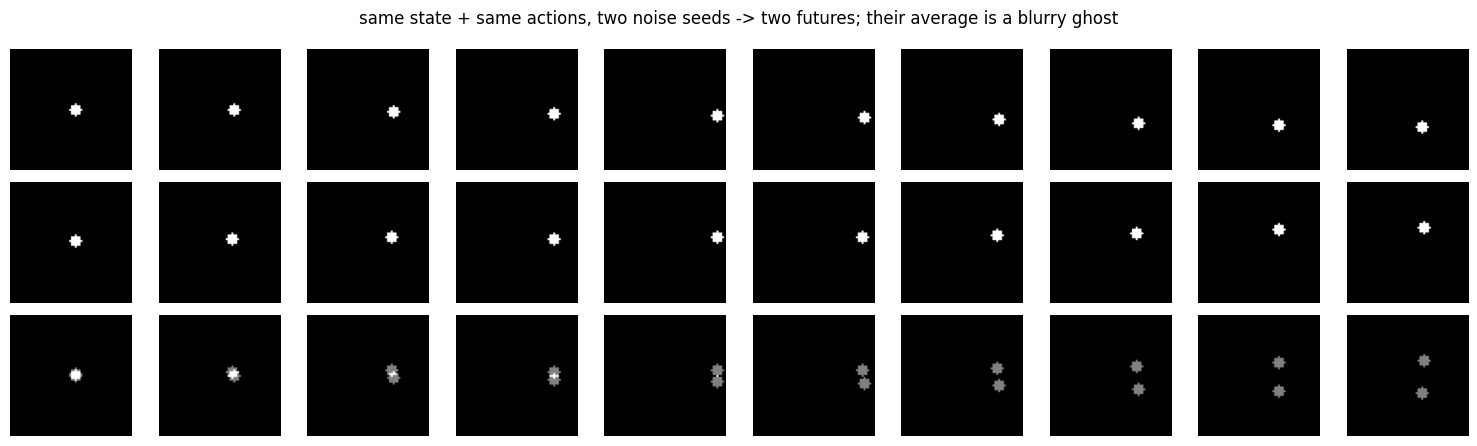

In [3]:
def continue_rollout(state, action_seq, seed):
    """same state, same actions, different noise -> a different future"""
    r = np.random.default_rng(seed)
    frames = []
    for a in action_seq:
        state = step_world(state, a, r)
        frames.append(render_ball(state[0], state[1]))
    return frames

state0 = (0.5, 0.5, 0.3, 0.1)
same_actions = [np.array([1, 0], dtype=np.float32)] * 10
future_A = continue_rollout(state0, same_actions, seed=1)
future_B = continue_rollout(state0, same_actions, seed=2)
average = [(a + b) / 2 for a, b in zip(future_A, future_B)]

fig, axes = plt.subplots(3, 10, figsize=(15, 4.5))
for j in range(10):
    axes[0, j].imshow(future_A[j], cmap="gray", vmin=0, vmax=1)
    axes[1, j].imshow(future_B[j], cmap="gray", vmin=0, vmax=1)
    axes[2, j].imshow(average[j], cmap="gray", vmin=0, vmax=1)
    for ax in axes[:, j]:
        ax.axis("off")
axes[0, 0].set_ylabel("future A", fontsize=10)
axes[1, 0].set_ylabel("future B", fontsize=10)
axes[2, 0].set_ylabel("平均", fontsize=10)
plt.suptitle("same state + same actions, two noise seeds -> two futures; their average is a blurry ghost")
plt.tight_layout()
plt.show()


## 4. Build the Model: Tiny RSSM

**Why this architecture:** 每个时间步携带两个状态——

- **确定性状态 $h_t$**（GRU hidden state）：无损地记住历史，管长程依赖；$h_t = \mathrm{GRU}([z_{t-1}, a_{t-1}],\, h_{t-1})$。
- **随机状态 $z_t$**：从对角高斯采样，承载"这一步环境可能怎么随机"；16 维。

围绕它们有三个可学习的分布/映射，全部用几行 PyTorch 显式写出：

| 组件 | 公式 | 实现 |
|---|---|---|
| Encoder | $e_t = \mathrm{enc}(x_t)$ | 3 层 strided conv → 128 维 embedding |
| Prior | $p_\theta(z_t \mid h_t) = \mathcal{N}(\mu_p(h_t), \sigma_p(h_t))$ | MLP，**不看**当前观测 |
| Posterior | $q_\theta(z_t \mid h_t, x_t) = \mathcal{N}(\mu_q(h_t, e_t), \sigma_q(h_t, e_t))$ | MLP，**看了**当前观测 |
| Decoder | $\hat{x}_t = \mathrm{dec}(h_t, z_t)$ | 镜像 transposed conv，输出 logits |

两个关键细节也显式实现：**reparameterization trick**（$z = \mu + \sigma \odot \epsilon$，噪声与参数无关，梯度照常流过 $\mu, \sigma$）和**闭式 KL**（两个对角高斯之间的 KL 有解析解，不需要采样估计）。`stochastic=False` 时同一个类退化为 deterministic baseline（$z$ 取均值、KL 换成 MSE），Section 8 用它做对照。

In [4]:
Z_DIM, H_DIM, E_DIM, A_DIM = 16, 64, 128, 2

class Encoder(nn.Module):
    """image x_t (1,64,64) -> embedding e_t (128)"""
    def __init__(self, e_dim=E_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 4, 2, 1), nn.ReLU(),    # 64 -> 32
            nn.Conv2d(16, 32, 4, 2, 1), nn.ReLU(),   # 32 -> 16
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),   # 16 -> 8
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, e_dim), nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    """(h_t, z_t) -> image logits (1,64,64); sigmoid 仅用于显示"""
    def __init__(self, in_dim=H_DIM + Z_DIM):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(in_dim, 128), nn.ReLU(),
                                nn.Linear(128, 64 * 8 * 8), nn.ReLU())
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),   # 8 -> 16
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.ReLU(),   # 16 -> 32
            nn.ConvTranspose2d(16, 1, 4, 2, 1),               # 32 -> 64, raw logits
        )

    def forward(self, h, z):
        return self.deconv(self.fc(torch.cat([h, z], -1)).view(-1, 64, 8, 8))

def gaussian_stats(raw, min_std=0.1):
    """MLP 输出 -> (mu, std); softplus + min_std 保证 std 为正且不塌缩到 0"""
    mu, raw_std = raw.chunk(2, dim=-1)
    return mu, F.softplus(raw_std) + min_std

def sample_gaussian(mu, std):
    """reparameterization trick: z = mu + std * eps, eps ~ N(0, I) 与参数无关"""
    return mu + std * torch.randn_like(std)

def kl_gaussian(mu_q, std_q, mu_p, std_p):
    """闭式 KL( N(mu_q,std_q^2) || N(mu_p,std_p^2) )，对 latent 维求和、对 batch 求均值"""
    var_q, var_p = std_q ** 2, std_p ** 2
    kl = torch.log(std_p / std_q) + (var_q + (mu_q - mu_p) ** 2) / (2 * var_p) - 0.5
    return kl.sum(-1).mean()

class TinyRSSM(nn.Module):
    def __init__(self, z_dim=Z_DIM, h_dim=H_DIM, stochastic=True):
        super().__init__()
        self.stochastic, self.z_dim, self.h_dim = stochastic, z_dim, h_dim
        self.enc = Encoder()
        self.gru = nn.GRUCell(z_dim + A_DIM, h_dim)                 # h_t = GRU([z,a], h)
        self.prior_net = nn.Sequential(nn.Linear(h_dim, 128), nn.ReLU(),
                                       nn.Linear(128, 2 * z_dim))   # p(z_t|h_t): 不看 x_t
        self.post_net = nn.Sequential(nn.Linear(h_dim + E_DIM, 128), nn.ReLU(),
                                      nn.Linear(128, 2 * z_dim))    # q(z_t|h_t,x_t): 看 x_t
        self.dec = Decoder(h_dim + z_dim)

    def prior(self, h):
        return gaussian_stats(self.prior_net(h))

    def posterior(self, h, e):
        return gaussian_stats(self.post_net(torch.cat([h, e], -1)))

    def observe(self, xs, acts):
        """teacher-forced 前向：每步 posterior 看真实帧。返回 (recon, kl, stats, recon_frames)"""
        B, T = xs.shape[:2]
        h = xs.new_zeros(B, self.h_dim); z = xs.new_zeros(B, self.z_dim)
        a_prev = xs.new_zeros(B, A_DIM)
        rec, kl, stats, recons = 0.0, 0.0, [], []
        for t in range(T):
            h = self.gru(torch.cat([z, a_prev], -1), h)             # 1) 确定性路径推进
            mu_p, std_p = self.prior(h)                             # 2) prior: 盲猜 z_t
            mu_q, std_q = self.posterior(h, self.enc(xs[:, t]))     # 3) posterior: 看 x_t 修正
            if self.stochastic:
                z = sample_gaussian(mu_q, std_q)                    # 4) reparameterization 采样
                kl = kl + kl_gaussian(mu_q, std_q, mu_p, std_p)     #    闭式 KL
            else:  # deterministic baseline: z 是点估计, 用 MSE 代替 KL 训练 prior
                z = mu_q
                kl = kl + F.mse_loss(mu_p, mu_q.detach())
            logits = self.dec(h, z)                                 # 5) 生成 x̂_t
            rec = rec + F.binary_cross_entropy_with_logits(
                logits, xs[:, t], pos_weight=POS_W, reduction="sum") / B  # 对像素求和(真正的 ELBO)，对 batch 取均值
            a_prev = acts[:, t]
            stats.append((mu_p.detach(), std_p.detach(), mu_q.detach(), std_q.detach()))
            recons.append(torch.sigmoid(logits.detach())[:, 0])
        return rec / T, kl / T, stats, torch.stack(recons, 1)

    @torch.no_grad()
    def imagine(self, x_ctx, a_ctx, a_fut):
        """burn-in 用 posterior 消化历史帧，然后只用 prior 开环想象未来"""
        B, Tc = x_ctx.shape[:2]
        h = x_ctx.new_zeros(B, self.h_dim); z = x_ctx.new_zeros(B, self.z_dim)
        a_prev = x_ctx.new_zeros(B, A_DIM)
        for t in range(Tc):                                         # burn-in: 看观测
            h = self.gru(torch.cat([z, a_prev], -1), h)
            mu_q, std_q = self.posterior(h, self.enc(x_ctx[:, t]))
            z = sample_gaussian(mu_q, std_q) if self.stochastic else mu_q
            a_prev = a_ctx[:, t]
        frames = []
        for k in range(a_fut.shape[1]):                             # imagination: 不看观测
            h = self.gru(torch.cat([z, a_fut[:, k]], -1), h)
            mu_p, std_p = self.prior(h)
            z = sample_gaussian(mu_p, std_p) if self.stochastic else mu_p
            frames.append(torch.sigmoid(self.dec(h, z))[:, 0])
        return torch.stack(frames, 1)                               # (B, T_fut, 64, 64)

POS_W = torch.tensor(10.0)   # 小球只占 ~0.7% 像素，正样本加权防"全黑"塌缩（同 Lab 2）
rssm = TinyRSSM(stochastic=True)
print(f"parameters: {sum(p.numel() for p in rssm.parameters()):,}  (tiny — CPU-friendly)")


parameters: 1,203,169  (tiny — CPU-friendly)


## 5. Train: ELBO = Reconstruction + β · KL

**Why these two terms:** 这是序列版 VAE 的 ELBO（证据下界）——

$$\mathcal{L} = \underbrace{\sum_t \mathrm{BCE}(\hat{x}_t, x_t)}_{\text{reconstruction: 重建每一帧}} + \beta \underbrace{\sum_t \mathrm{KL}\big(q(z_t|h_t,x_t)\,\|\,p(z_t|h_t)\big)}_{\text{KL: posterior 不许偏离 prior 太远}}$$

**为什么训练时用 posterior？** 因为重建损失需要一个"知道答案"的 $z_t$：posterior 看到了 $x_t$，能给出足够精确的 latent 让 decoder 重建成功，梯度才能流回 encoder/decoder/GRU。**那为什么不放任 posterior 随便用观测信息？** 因为想象时（下一节）没有 $x_t$ 可看，只能用 prior——如果 posterior 携带的信息 prior 完全猜不到，模型就永远学不会"盲走"。KL 项正是对齐两者的桥梁：它惩罚"只有看了答案才知道的信息"，强迫 prior 学着预测 posterior。$\beta=1$ 是标准 ELBO；$\beta$ 太小则 prior 学不到东西，太大则 posterior 不敢用观测（posterior collapse），Exercise 2 会亲手看到这个 trade-off

**一个容易踩的坑（我们亲手踩过）：** BCE 默认对像素取 `mean`，重建项数值只有 ~0.05–0.7，而 KL 是对 latent 维**求和**的 nats（~1–20）——量纲失衡会让任何 $\beta \geq 0.1$ 都把 posterior 压垮（collapse）。真正的 ELBO 是对像素**求和**的 log-likelihood；本 notebook 用 `reduction="sum"` 保持这个比例，$\beta=1$ 即可稳定训练。

step  150/500  recon(sum-BCE) 1000.7  KL 0.14


step  300/500  recon(sum-BCE) 1012.4  KL 0.36


step  450/500  recon(sum-BCE) 87.9  KL 18.67


trained in 237.8s on CPU


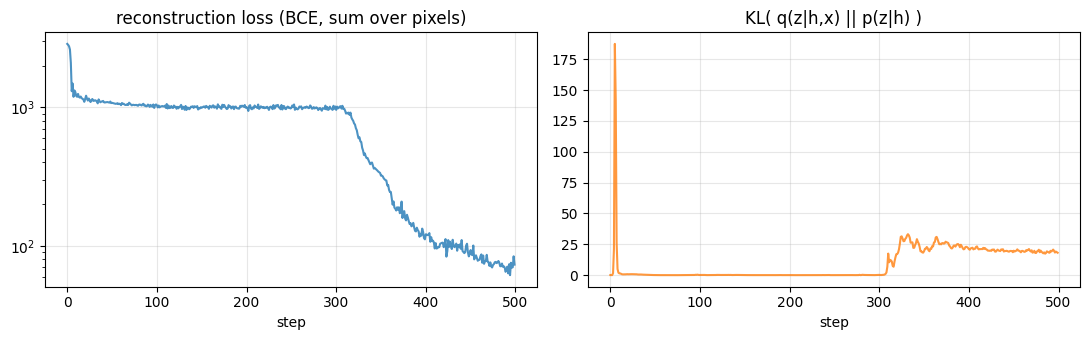

In [5]:
SEQ_LEN, BATCH, STEPS, BETA, LR = 12, 24, 500, 1.0, 3e-3

def sample_seq_batch(rng, batch=BATCH, seq_len=SEQ_LEN):
    """随机采 batch 个长度为 seq_len 的连续片段"""
    ep = rng.integers(0, N_EP, batch)
    st = rng.integers(0, EP_LEN - seq_len, batch)
    idx = st[:, None] + np.arange(seq_len)[None, :]
    return frames_t[ep[:, None], idx], actions_t[ep[:, None], idx]

def train(model, steps, beta=BETA, log_every=150, seed=1):
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    tr = np.random.default_rng(seed)
    hist = []
    t0 = time.time()
    model.train()
    for step in range(steps):
        xs, ac = sample_seq_batch(tr)
        rec, kl, _, _ = model.observe(xs, ac)
        loss = rec + beta * kl
        opt.zero_grad()
        loss.backward()
        opt.step()
        hist.append((rec.item(), kl.item()))
        if (step + 1) % log_every == 0:
            print(f"step {step+1:4d}/{steps}  recon(sum-BCE) {rec.item():.1f}  KL {kl.item():.2f}")
    print(f"trained in {time.time() - t0:.1f}s on CPU")
    return np.array(hist)

hist = train(rssm, STEPS)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(hist[:, 0], color="tab:blue", alpha=0.8)
axes[0].set_yscale("log"); axes[0].set_xlabel("step")
axes[0].set_title("reconstruction loss (BCE, sum over pixels)")
axes[1].plot(hist[:, 1], color="tab:orange", alpha=0.8)
axes[1].set_xlabel("step"); axes[1].set_title("KL( q(z|h,x) || p(z|h) )")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Visualize ① — Observation Reconstruction

**Why check reconstruction first:** 如果模型连"看着 $x_t$ 重建 $x_t$"都做不到，后面一切都是空谈。下面沿时间轴展开一个完整 episode：每一步 posterior 看到真实帧后采样 $z_t$，decoder 从 $(h_t, z_t)$ 重建。清晰的小球说明 $(h_t, z_t)$ 确实编码了球的位形。

episode 0: recon(sum-BCE) 66.7, mean KL per step 19.77


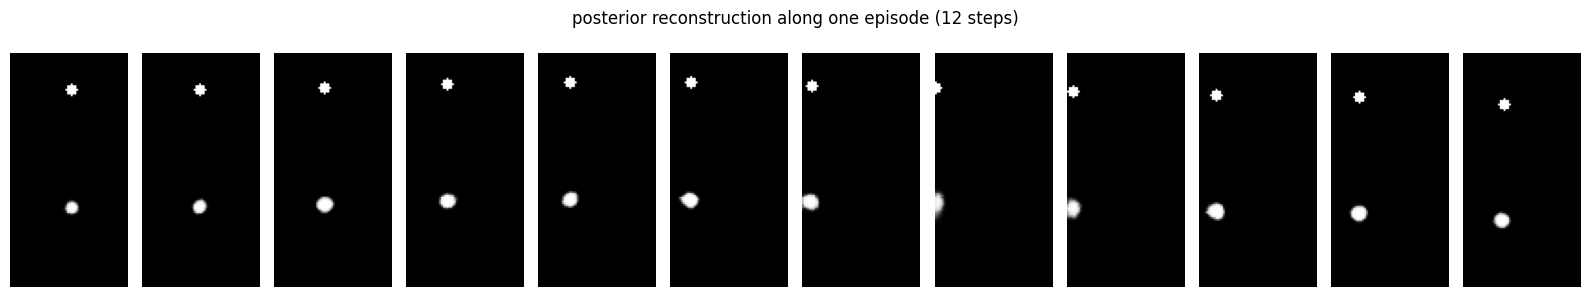

In [6]:
rssm.eval()
with torch.no_grad():
    ep_i = 0
    xs = frames_t[ep_i:ep_i + 1, :12]
    ac = actions_t[ep_i:ep_i + 1, :12]
    rec, kl, _, recons = rssm.observe(xs, ac)
print(f"episode {ep_i}: recon(sum-BCE) {rec.item():.1f}, mean KL per step {kl.item():.2f}")

fig, axes = plt.subplots(2, 12, figsize=(16, 3))
for j in range(12):
    axes[0, j].imshow(xs[0, j, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, j].imshow(recons[0, j], cmap="gray", vmin=0, vmax=1)
    for ax in axes[:, j]:
        ax.axis("off")
axes[0, 0].set_ylabel("input $x_t$", fontsize=10)
axes[1, 0].set_ylabel("recon $\hat{x}_t$", fontsize=10)
plt.suptitle("posterior reconstruction along one episode (12 steps)")
plt.tight_layout()
plt.show()


## 6. Visualize ② — Prior vs Posterior

**Why compare them:** prior 是"盲猜"，posterior 是"看了答案"。两者的差距就是观测提供的信息量，也正是 KL 在缩小的东西。预期看到：(a) posterior 的 std 普遍小于 prior（看了观测更确定）；(b) 两者的均值分布形状相近但不重合；(c) KL 在各 latent 维上分布不均——少数维承担大部分信息。

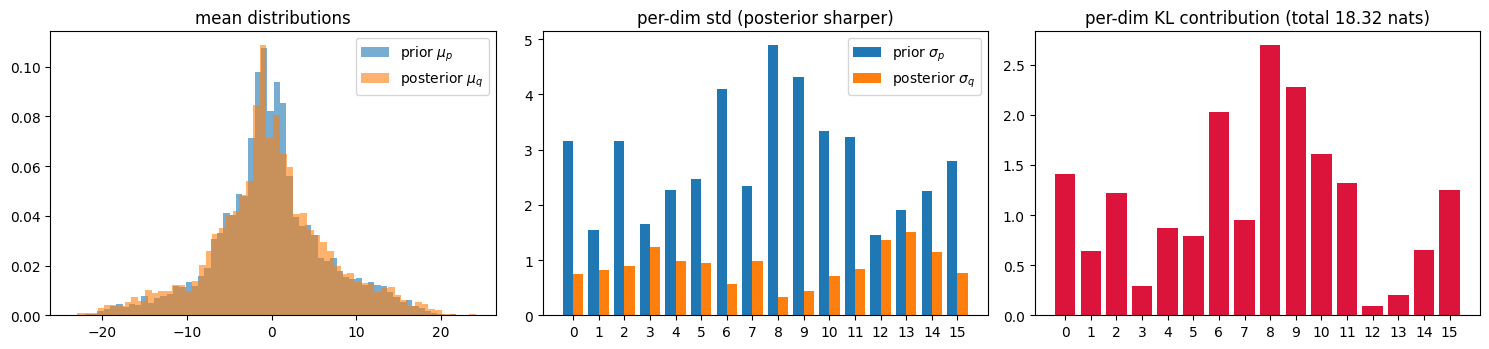

In [7]:
xs, ac = sample_seq_batch(np.random.default_rng(3), batch=64, seq_len=12)
with torch.no_grad():
    _, kl_now, stats, _ = rssm.observe(xs, ac)
mu_p = torch.cat([s[0] for s in stats]); std_p = torch.cat([s[1] for s in stats])
mu_q = torch.cat([s[2] for s in stats]); std_q = torch.cat([s[3] for s in stats])

# per-dim KL contribution (analytic, averaged over batch*time)
var_q, var_p = std_q ** 2, std_p ** 2
kl_per_dim = (torch.log(std_p / std_q) + (var_q + (mu_q - mu_p) ** 2) / (2 * var_p) - 0.5).mean(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].hist(mu_p.numpy().ravel(), bins=60, alpha=0.6, density=True, label="prior $\mu_p$")
axes[0].hist(mu_q.numpy().ravel(), bins=60, alpha=0.6, density=True, label="posterior $\mu_q$")
axes[0].legend(); axes[0].set_title("mean distributions")
dims = np.arange(Z_DIM)
axes[1].bar(dims - 0.2, std_p.mean(0), width=0.4, label="prior $\sigma_p$")
axes[1].bar(dims + 0.2, std_q.mean(0), width=0.4, label="posterior $\sigma_q$")
axes[1].set_xticks(dims); axes[1].legend(); axes[1].set_title("per-dim std (posterior sharper)")
axes[2].bar(dims, kl_per_dim.numpy(), color="crimson")
axes[2].set_xticks(dims); axes[2].set_title(f"per-dim KL contribution (total {kl_now.item():.2f} nats)")
plt.tight_layout()
plt.show()


## 7. Evaluate ① — One-Step Prediction

**Why:** imagination 的原子操作：已知历史 $h_t$（由 burn-in 建立），在**看到 $x_t$ 之前**从 prior 采样 $z_t$ 并解码，应该接近真实的 $x_t$。这相当于 Kalman Filter 的 predict 步。下面同时画出 posterior 重建作为对照——prior 版应该大体正确但略模糊/略偏，因为它少看了当前帧。

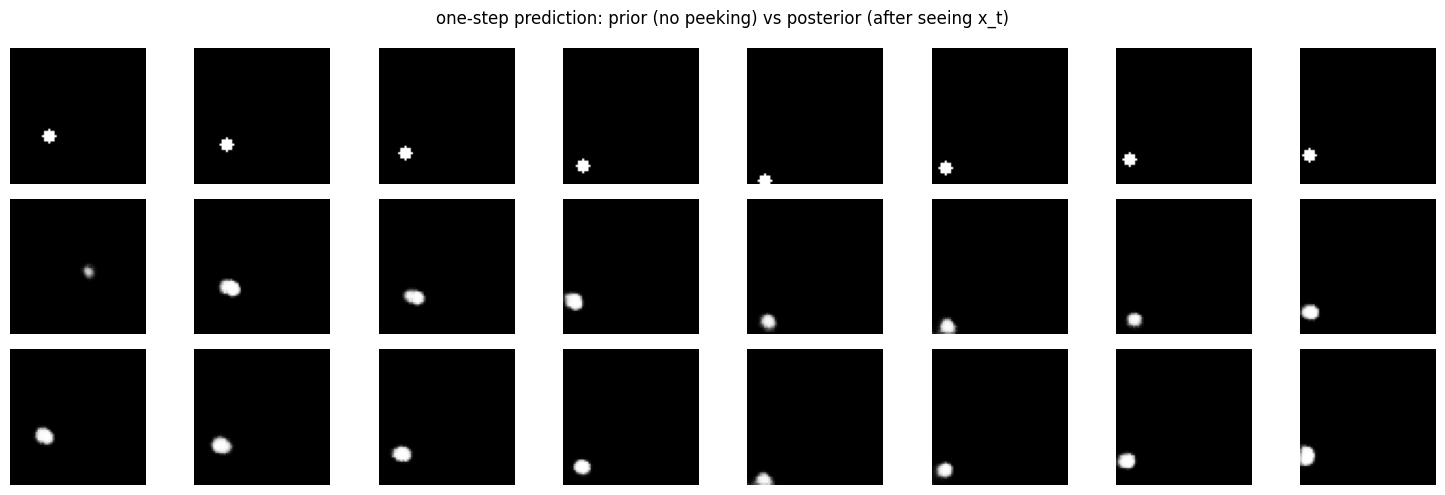

In [8]:
@torch.no_grad()
def one_step_predictions(model, xs, ac):
    """对每步 t：先由 prior 预测 x_t（不看 x_t），再由 posterior 重建（看 x_t）"""
    B, T = xs.shape[:2]
    h = xs.new_zeros(B, H_DIM); z = xs.new_zeros(B, Z_DIM); a_prev = xs.new_zeros(B, A_DIM)
    prior_frames, post_frames = [], []
    for t in range(T):
        h = model.gru(torch.cat([z, a_prev], -1), h)
        mu_p, std_p = model.prior(h)
        z_prior = sample_gaussian(mu_p, std_p)
        prior_frames.append(torch.sigmoid(model.dec(h, z_prior))[0, 0])   # 盲预测
        mu_q, std_q = model.posterior(h, model.enc(xs[:, t]))
        z = sample_gaussian(mu_q, std_q)
        post_frames.append(torch.sigmoid(model.dec(h, z))[0, 0])          # 看了再重建
        a_prev = ac[:, t]
    return prior_frames, post_frames

ep_i = 1
xs1 = frames_t[ep_i:ep_i + 1, :8]; ac1 = actions_t[ep_i:ep_i + 1, :8]
prior_f, post_f = one_step_predictions(rssm, xs1, ac1)

fig, axes = plt.subplots(3, 8, figsize=(15, 5))
for j in range(8):
    axes[0, j].imshow(xs1[0, j, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, j].imshow(prior_f[j], cmap="gray", vmin=0, vmax=1)
    axes[2, j].imshow(post_f[j], cmap="gray", vmin=0, vmax=1)
    for ax in axes[:, j]:
        ax.axis("off")
axes[0, 0].set_ylabel("true $x_t$", fontsize=10)
axes[1, 0].set_ylabel("prior 预测", fontsize=10)
axes[2, 0].set_ylabel("posterior 重建", fontsize=10)
plt.suptitle("one-step prediction: prior (no peeking) vs posterior (after seeing x_t)")
plt.tight_layout()
plt.show()


## 7. Evaluate ② — Multi-Step Imagination Rollout（只用 prior）

**Why this is the payoff:** 给模型 4 帧历史（burn-in，用 posterior 消化），然后**再也不给任何观测**——只给未来的动作序列，让模型在潜空间里开环想象 15 帧：

$$h_{k+1} = \mathrm{GRU}([z_k, a_k], h_k), \qquad z_{k+1} \sim p_\theta(z_{k+1} \mid h_{k+1}), \qquad \hat{x}_{k+1} = \mathrm{dec}(h_{k+1}, z_{k+1})$$

**为什么想象时必须用 prior？** 因为 posterior $q(z_t|h_t,x_t)$ 的输入里有 $x_t$——而未来帧根本不存在。这是 RSSM 训练-测试不对称的根源：训练时 posterior 当"老师"，KL 把知识蒸馏给 prior；想象时 prior 独自上场。下面的拼图把想象（下行）和 ground truth（上行）并排。注意想象**不应该**逐像素等于真值——环境是随机的，真值只是多种合理未来之一；合理的想象应该是一颗**清晰、运动合理**的球。

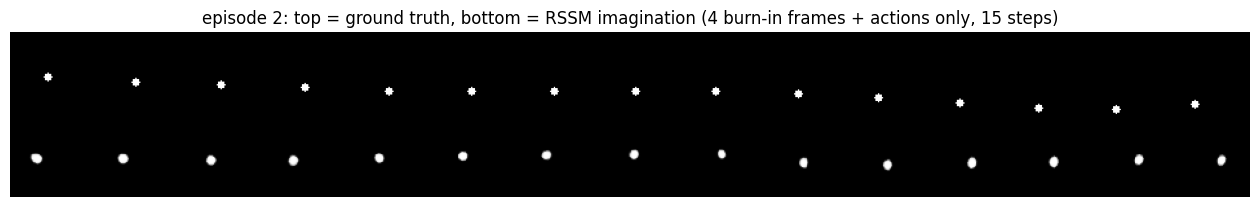

saved assets/imagination_grid.png and assets/imagination_rollout.gif


In [9]:
BURN, HORIZON = 4, 15
EP = 2
x_ctx = frames_t[EP:EP + 1, :BURN]
a_ctx = actions_t[EP:EP + 1, :BURN]
a_fut = actions_t[EP:EP + 1, BURN - 1:BURN - 1 + HORIZON]   # a_{BURN-1} 驱动第一个想象帧

imagined = rssm.imagine(x_ctx, a_ctx, a_fut)[0]              # (HORIZON, 64, 64)
gt = frames_np[EP, BURN:BURN + HORIZON]

grid = np.concatenate([np.concatenate(gt, axis=1), np.concatenate(imagined.numpy(), axis=1)], axis=0)
plt.figure(figsize=(16, 2.6))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title(f"episode {EP}: top = ground truth, bottom = RSSM imagination (4 burn-in frames + actions only, 15 steps)")
plt.savefig("assets/imagination_grid.png", dpi=110, bbox_inches="tight")
plt.show()

side_by_side = [np.concatenate([g, d], axis=1) for g, d in zip(gt, imagined.numpy())]
imageio.mimsave("assets/imagination_rollout.gif",
                [(f * 255).astype(np.uint8) for f in side_by_side], duration=0.25)
print("saved assets/imagination_grid.png and assets/imagination_rollout.gif")


## 7. Evaluate ③ — 多次想象：一个历史，多个未来

**Why:** stochastic latent 的招牌能力。固定同样的 burn-in 和动作，只改采样噪声，连做 3 次 imagination。deterministic 模型这里会输出 3 次完全相同（且模糊）的序列；RSSM 应该给出 3 条**各自清晰、互不相同**的轨迹——未来的分布，而不是未来的平均。

mean pixel-wise std across 3 dreams: 0.014  (0 = 确定性模型)


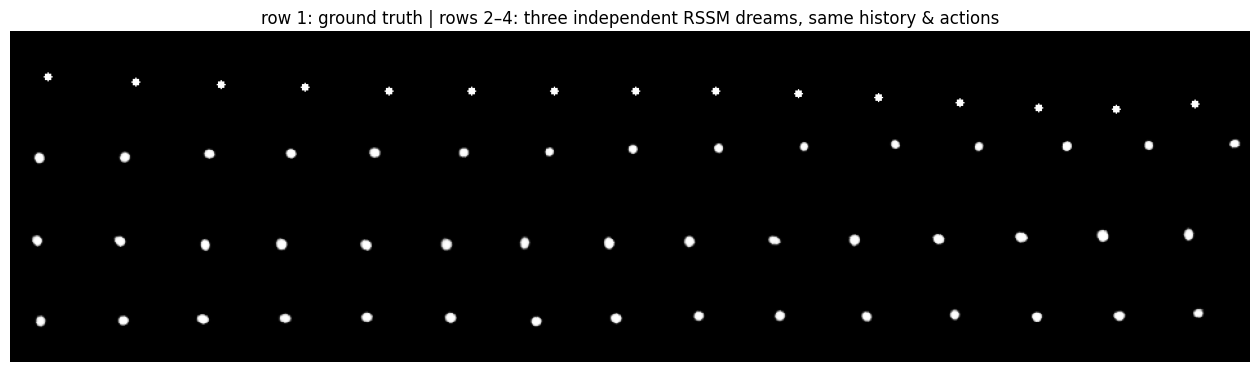

In [10]:
dreams = [rssm.imagine(x_ctx, a_ctx, a_fut)[0].numpy() for _ in range(3)]
stack = np.stack(dreams)                                     # (3, HORIZON, 64, 64)
pixel_std = stack.std(axis=0).mean()
print(f"mean pixel-wise std across 3 dreams: {pixel_std:.3f}  (0 = 确定性模型)")

rows = [np.concatenate(gt, axis=1)] + [np.concatenate(d, axis=1) for d in dreams]
grid = np.concatenate(rows, axis=0)
plt.figure(figsize=(16, 5))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("row 1: ground truth | rows 2–4: three independent RSSM dreams, same history & actions")
plt.savefig("assets/multi_dreams.png", dpi=110, bbox_inches="tight")
plt.show()


## 8. Experiment: Deterministic-Only Baseline —— 为什么纯 RNN 不够

现在正面回答第一个教学问题。训练一个**结构完全相同**的 baseline，唯一区别是去掉随机性：$z_t$ 直接取 posterior 均值（不采样），KL 换成 MSE 让 prior 网络学着预测它。这就是"deterministic RNN world model"（Lab 2 模型的 GRU 版）。

**预测：** deterministic 模型结构上没有随机性，imagination 只能输出**一条**轨迹——它学到的是所有可能未来的某种“平均轨迹”，清晰、自信，但常常偏离任何一个实际发生的未来。RSSM 则采样出多条各自合理的轨迹，其中往往有一条贴近真值。另外：如果把 RSSM 的多个 dream 在像素空间平均，就会看到“条件均值”真正的样子——一团模糊重影（正是 Section 3.1 的现象）。

step  150/320  recon(sum-BCE) 795.3  KL 38.83


step  300/320  recon(sum-BCE) 62.5  KL 191.71


trained in 127.5s on CPU


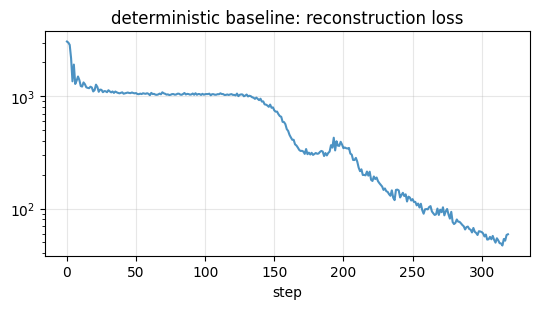

In [11]:
det = TinyRSSM(stochastic=False)     # 同结构，无随机状态
hist_det = train(det, steps=320)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(hist_det[:, 0], color="tab:blue", alpha=0.8)
ax.set_yscale("log"); ax.set_xlabel("step")
ax.set_title("deterministic baseline: reconstruction loss")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


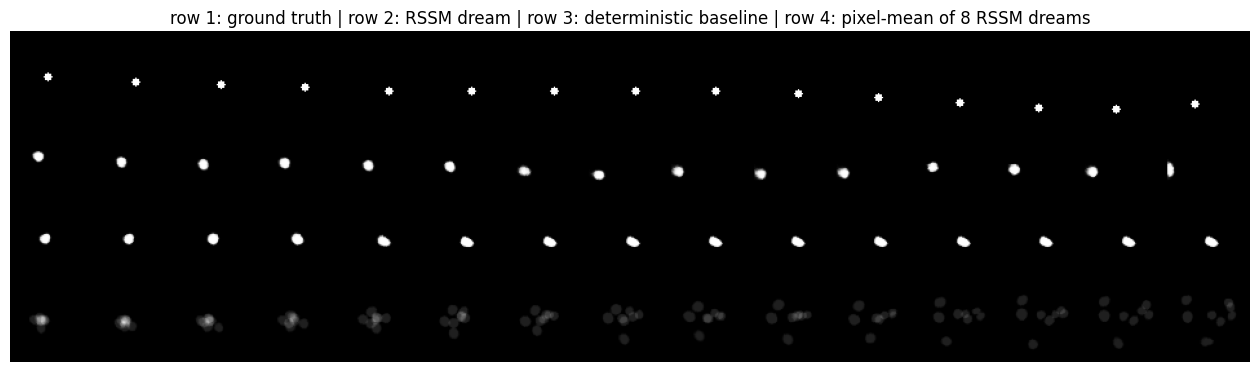

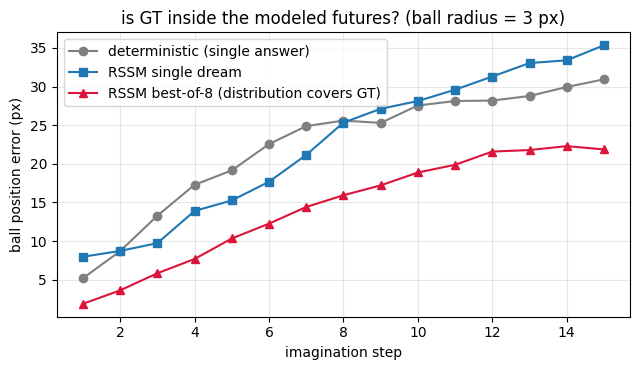

RSSM 预测的位置 spread (px): step1 2.4 -> step15 8.3
deterministic 的 spread: 0.0 (结构上无法表达不确定性)
step 15 位置误差: det 30.9px | RSSM 单次 35.4px | RSSM best-of-8 21.9px


In [12]:
det_imagined = det.imagine(x_ctx, a_ctx, a_fut)[0].numpy()
rssm_imagined = rssm.imagine(x_ctx, a_ctx, a_fut)[0].numpy()
dreams8_ep = torch.stack([rssm.imagine(x_ctx, a_ctx, a_fut) for _ in range(8)])[:, 0].numpy()
mean_dream = dreams8_ep.mean(0)          # 像素空间的条件均值 ≈ "只许预测一帧"的最优解

rows = [np.concatenate(gt, axis=1),
        np.concatenate(rssm_imagined, axis=1),
        np.concatenate(det_imagined, axis=1),
        np.concatenate(mean_dream, axis=1)]
grid = np.concatenate(rows, axis=0)
plt.figure(figsize=(16, 5))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("row 1: ground truth | row 2: RSSM dream | row 3: deterministic baseline | row 4: pixel-mean of 8 RSSM dreams")
plt.savefig("assets/rssm_vs_deterministic.png", dpi=110, bbox_inches="tight")
plt.show()

# 在 32 个 episode 上批量评估, 避免单例偶然性
ev = np.random.default_rng(5)
eps_idx = ev.integers(0, N_EP, 32)
xc = frames_t[eps_idx, :BURN]; acx = actions_t[eps_idx, :BURN]
af = actions_t[eps_idx, BURN - 1:BURN - 1 + HORIZON]
gt_batch = frames_t[eps_idx, BURN:BURN + HORIZON, 0]                   # (32, H, 64, 64)
rssm_batch = rssm.imagine(xc, acx, af)
det_batch = det.imagine(xc, acx, af)
dreams8 = torch.stack([rssm.imagine(xc, acx, af) for _ in range(8)])   # (8, 32, H, 64, 64)

def ball_position(frames):
    """threshold -> center of mass, returns (..., 2) 像素坐标"""
    w = (np.asarray(frames) > 0.5).astype(np.float32)
    yy, xx = np.mgrid[0:SIZE, 0:SIZE]
    tot = w.sum(axis=(-2, -1)) + 1e-8
    return np.stack([(w * xx).sum(axis=(-2, -1)) / tot,
                     (w * yy).sum(axis=(-2, -1)) / tot], axis=-1)

gt_pos = ball_position(gt_batch.numpy())                      # (32, H, 2)
det_pos = ball_position(det_batch.numpy())
dreams_pos = ball_position(dreams8.numpy())                   # (8, 32, H, 2)

det_err = np.linalg.norm(det_pos - gt_pos, axis=-1).mean(0)               # (H,)
rssm_err = np.linalg.norm(ball_position(rssm_batch.numpy()) - gt_pos, axis=-1).mean(0)
best_err = np.linalg.norm(dreams_pos - gt_pos, axis=-1).min(0).mean(0)    # best-of-8

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(range(1, HORIZON + 1), det_err, "o-", label="deterministic (single answer)", color="gray")
ax.plot(range(1, HORIZON + 1), rssm_err, "s-", label="RSSM single dream", color="tab:blue")
ax.plot(range(1, HORIZON + 1), best_err, "^-", label="RSSM best-of-8 (distribution covers GT)", color="crimson")
ax.set_xlabel("imagination step"); ax.set_ylabel("ball position error (px)")
ax.set_title("is GT inside the modeled futures? (ball radius = 3 px)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

spread = dreams_pos.std(axis=0).mean(axis=(0, 2))             # (H,) RSSM 预测的未来发散程度
print(f"RSSM 预测的位置 spread (px): step1 {spread[0]:.1f} -> step15 {spread[-1]:.1f}")
print(f"deterministic 的 spread: 0.0 (结构上无法表达不确定性)")
print(f"step 15 位置误差: det {det_err[-1]:.1f}px | RSSM 单次 {rssm_err[-1]:.1f}px | RSSM best-of-8 {best_err[-1]:.1f}px")

### 8.1 结果分析：三个问题的答案

把上面的实验证据拼起来：

1. **为什么纯 deterministic RNN 不够？** 环境本身随机（Section 3.1：同状态同动作、不同噪声 → 不同未来；10–15 步后位置不确定可达 ±10–15 px，而球半径只有 3 px）。deterministic 模型结构上没有随机性，只能提交**一条**轨迹——它收敛到"平均轨迹"：清晰、自信，但常常不等于任何实际发生的未来。
2. **为什么需要 stochastic latent state？** deterministic 模型与 RSSM 的单次采样都会随 horizon 偏离真值，但 RSSM 的 best-of-8 明显更接近——真值落在它给出的分布里；它的 dream 位置 spread 也随 horizon 增长，正对应真实世界不断增长的不确定性，而 deterministic 模型的 spread 在结构上恒为 0。
3. **为什么训练用 posterior、想象用 prior？** 训练时需要一个"看过 $x_t$"的 latent 才能重建成功；想象时根本没有 $x_t$ 可看。KL 项在两者之间架桥，所以 prior 独自上场也能生成清晰、合理的多步 dream。

### ✏️ Exercise 1 — Latent dimension

把 `Z_DIM` 改成 4 和 32 重新训练（改 `rssm = TinyRSSM(z_dim=..., ...)` 并重跑 Section 5–7）。观察：KL 总量、重建质量、imagination 清晰度如何变化？这个任务"够用"的最小维度是多少，和世界的内在维度（位置+速度 ≈ 4 维）什么关系？

**Hint:** 维度太小会先牺牲重建（球变形），太大则 KL 项变贵、prior 更难学。

In [13]:
# YOUR CODE HERE
# hint: rssm4 = TinyRSSM(z_dim=4, stochastic=True); hist4 = train(rssm4, 400)
pass


### ✏️ Exercise 2 — KL weight β

用 `beta=0.0`（关闭 KL）和 `beta=10.0`（KL 主导）重新训练 RSSM，对比：(a) Section 6 的 prior/posterior std 图；(b) imagination 质量。你应看到两种经典失败模式：β=0 时 posterior 自由携带信息、prior 掉队，imagination 崩溃；β 过大时 posterior 不敢偏离 prior（**posterior collapse**），重建变糊。

**Hint:** `train(model, steps, beta=0.0)`；DreamerV3 用 free bits / KL balancing 等技巧缓解这个 trade-off。

In [14]:
# YOUR CODE HERE
# hint: rssm_b0 = TinyRSSM(stochastic=True); hist_b0 = train(rssm_b0, 400, beta=0.0)
pass


### ✏️ Exercise 3 — Sequence length & noise level

两个方向任选（或都做）：

1. 把 `SEQ_LEN` 改成 4 和 18 重训：训练序列越短，GRU 学到的长程依赖越弱，长 horizon imagination 会发生什么？
2. 把 `NOISE_STD` 改成 0（回到确定性世界）重生成数据并对比 RSSM vs baseline：环境不随机时，stochastic latent 还有优势吗？KL 会怎么变？

**Hint:** 改 `NOISE_STD` 后需要重跑 Section 3 的数据生成 cell；观察 deterministic baseline 在 `NOISE_STD=0` 时是否不再模糊。

In [15]:
# YOUR CODE HERE
pass


## 9. Questions — Check Your Understanding

1. deterministic baseline 的 imagination 为什么模糊，而 RSSM 的样本保持清晰？用"条件均值 vs 采样"解释。
2. 训练时能不能只用 prior（完全不让 posterior 看 $x_t$）？重建损失会变成什么样？
3. 想象时为什么**不能**用 posterior？它的输入里缺了什么？
4. KL 项强迫 prior 向 posterior 靠拢。为什么不是反过来（强迫 posterior 迁就 prior）？
5. burn-in 阶段（imagination 的前几步）在做什么？没有它， imagination 从哪里开始？

## 10. Takeaways

- 你在 CPU 上几分钟内从零训练了一个**最小 RSSM**：`h_t = GRU(h_{t-1}, z_{t-1}, a_{t-1})` 管记忆，`z_t ~ p(z_t|h_t)` 管不确定性，posterior $q(z_t|h_t,x_t)$ 管观测校正，ELBO（recon + β·KL）管训练。全部核心逻辑（GRU cell、高斯采样、reparameterization、闭式 KL）都是可见的 PyTorch 代码。
- **deterministic-only baseline 的模糊平均**不是 bug 而是数学必然：在随机世界上，点估计模型的最优解是条件均值。stochastic latent 用"采样"代替"平均"，给出清晰且多样的未来。
- **posterior 训练 / prior 想象**的不对称由 KL 弥合——这是 PlaNet 到 DreamerV3 一以贯之的训练范式。
- 下一步（Lab 4）：在这个学到的世界模型内部做规划——在 imagination 里评估候选动作序列（MPC/CEM），完全不动真环境。

**Related modules:** [Scientist 06 · RSSM](/docs/scientist/06-rssm) · [Scientist 05 · Latent Dynamics](/docs/scientist/05-latent-dynamics)

**Related papers:** Hafner et al. (2019), *PlaNet / RSSM* ([arXiv:1811.04551](https://arxiv.org/abs/1811.04551)); Hafner et al. (2020), *Dreamer* ([arXiv:1912.01603](https://arxiv.org/abs/1912.01603)); Hafner et al. (2021), *DreamerV2* ([arXiv:2010.02193](https://arxiv.org/abs/2010.02193)).